# **Week 1: May 14 - 20**

### Note about the images
In both images: 
+ Size 2048x2048 (size of the CCD), 30 subs stacked together for each
+ Some sorts of streaks in the middle region (damages to the CCD?)
+ Bad column from x $\approx$ 895-960
+ Some sorts of surrounding dust in the outer region of the CCD

In image 152, the bad columns appeared different over time, as opposed to image 162

### Plot last images of every Cube

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from astropy.io import fits
from astropy.wcs import WCS

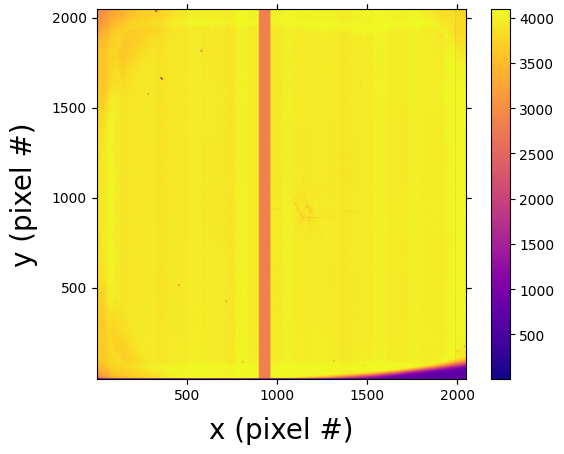

In [2]:
# Extract image data & header and parse the WCS information
image_1_data = fits.getdata("linearity/test/lm_260429_000152.fits")
image_1_header = fits.getheader("linearity/test/lm_260429_000152.fits")
wcs = WCS(image_1_header)

fig, ax = plt.subplots(subplot_kw=(dict(projection=wcs,slices=(30,"x","y"))))
color_ax = ax.imshow(image_1_data[29,:,:],origin="lower",cmap="plasma")
fig.colorbar(color_ax, ax=ax)
plt.xlabel('x (pixel #)', size = 20)
plt.ylabel('y (pixel #)', size = 20)
plt.show()

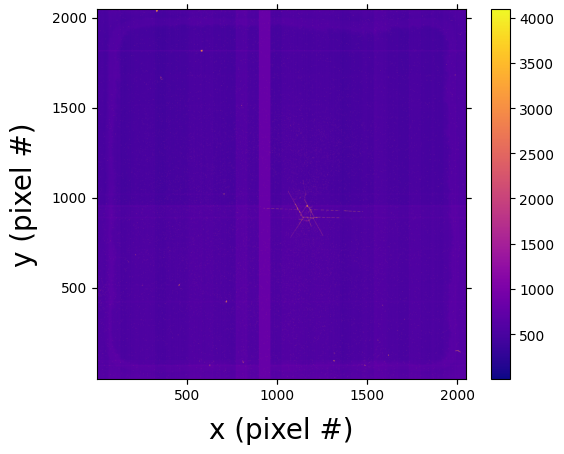

In [3]:
image_2_data = fits.getdata("linearity/test/lm_260429_000162.fits")
image_2_header = fits.getheader("linearity/test/lm_260429_000162.fits")
wcs = WCS(image_2_header)

fig, ax = plt.subplots(subplot_kw=(dict(projection=wcs,slices=(30,"x","y"))))
color_ax = ax.imshow(image_2_data[29,:,:],origin="lower",cmap="plasma")
fig.colorbar(color_ax, ax=ax)
plt.xlabel('x (pixel #)', size = 20)
plt.ylabel('y (pixel #)', size = 20)
plt.show()

## Compute the difference between two images and save to new FITS file

In [4]:
diff = image_2_data-image_1_data

diff_image = fits.PrimaryHDU(diff)
diff_image.writeto("diff.fits", overwrite=True)

### Note about difference image:
More vignettes at the corners of the image (non-uniform as in the bottom right corner)

Streaks in the middle region of the images remain 



# **Week 2: May 21 - 27**

## Appendix: Query all images

In [5]:
# import requests
# from io import BytesIO
# from zipfile import ZipFile

# url = "https://archive.lbto.org/files/lbt/lm_260429_000001.fits.gz"
# extract_to = "my_folder"

# # 1. Download the file content
# response = requests.get(url)

# # 2. Open the zip file in memory using BytesIO
# with ZipFile(BytesIO(response.content)) as zfile:
#     # 3. Extract all contents to the specified directory
#     zfile.extractall(extract_to)

# print(f"Extraction to '{extract_to}' completed.")


In [6]:
import glob

## 1) Make difference images

### a) Linearity fast

Take the average of all light frames to create one combined light image

In [7]:
# Call in all file names for linearity images
fast_light_filenames = glob.glob('linearity\\fast_light\\*')

# Create an empty directory store the data from light frames
fast_light_frames = [None] * len(fast_light_filenames)

# Extract data from our set of light frames
for i, filename in enumerate(fast_light_filenames):
    image_data = fits.getdata(filename)
    fast_light_frames[i] = image_data
fast_light_frames = np.array(fast_light_frames)

# Create the combined image
fast_superlight = np.average(fast_light_frames,axis=0)
print(fast_superlight.shape)

(30, 2048, 2048)


Save the combined light image to a new FITS file

In [ ]:
# Extract the header of the first light frame
info_light = fits.getheader(fast_light_filenames[0])

# Add reduction notes to header
lights_hdr = fits.Header()
lights_hdr = info_light
lights_hdr["Reduction"] = "Averaging 10 light frames with exposure of 3.2124s each"

# Write the combined light image data with updated header to a new FITS file
combined_light = fits.PrimaryHDU(data=fast_superlight, header=lights_hdr)
combined_light.writeto("linearity/fast_combined_light.fits", overwrite=True)

Take the average of all dark frames to create one combined dark image

In [9]:
# Call in all file names for linearity images
fast_dark_filenames = glob.glob('linearity\\fast_dark\\*')

# Create an empty directory store the data from light frames
fast_dark_frames = [None] * len(fast_dark_filenames)

# Extract data from our set of light frames
for i, filename in enumerate(fast_dark_filenames):
    image_data = fits.getdata(filename)
    fast_dark_frames[i] = image_data
fast_dark_frames = np.array(fast_dark_frames)

# Create the combined image
fast_superdark = np.average(fast_dark_frames,axis=0)
print(fast_superdark.shape)

(30, 2048, 2048)


Save the combined dark image to a new FITS file

In [ ]:
# Extract the header of the first dark frame
info_dark = fits.getheader(fast_dark_filenames[0])

# Add reduction notes to header
darks_hdr = fits.Header()
darks_hdr = info_dark
darks_hdr["Reduction"] = "Averaging 10 dark frames with exposure of 3.2124s each"

# Write the combined dark image data with updated header to a new FITS file
combined_dark = fits.PrimaryHDU(data=fast_superdark, header=darks_hdr)
combined_dark.writeto("linearity/fast_combined_dark.fits", overwrite=True)

Compute the difference between two combined images and save to new FITS file

In [11]:
# Compute the difference
fastdiff = fast_superlight - fast_superdark

# Merge header from combined light frame and add reduction notes
diffs_hdr = fits.getheader("linearity/fast_combined_light.fits")
diffs_hdr["Reduction"] += " and subtract the combined dark frame from the combined light frame"

# Write the difference image data with updated header to a new FITS file
combined_diff = fits.PrimaryHDU(data=fastdiff, header=diffs_hdr)
combined_diff.writeto("linearity/fast_diff.fits", overwrite=True)

### b) Linearity medium

Take the average of all light frames to create one combined light image

In [12]:
# Call in all file names for linearity images
medium_light_filenames = glob.glob('linearity\\medium_light\\*')

# Create an empty directory store the data from light frames
medium_light_frames = [None] * len(medium_light_filenames)

# Extract data from our set of light frames
for i, filename in enumerate(medium_light_filenames):
    image_data = fits.getdata(filename)
    medium_light_frames[i] = image_data
medium_light_frames = np.array(medium_light_frames)

# Create the combined image
medium_superlight = np.average(medium_light_frames,axis=0)
print(medium_superlight.shape)

(30, 2048, 2048)


Save the combined light image to a new FITS file

In [ ]:
# Extract the header of the first light frame
info_light = fits.getheader(medium_light_filenames[0])

# Add reduction notes to header
lights_hdr = fits.Header()
lights_hdr = info_light
lights_hdr["Reduction"] = "Averaging 11 light frames with exposure of 29.0138s each"

# Write the combined light image data with updated header to a new FITS file
combined_light = fits.PrimaryHDU(data=medium_superlight, header=lights_hdr)
combined_light.writeto("linearity/medium_combined_light.fits", overwrite=True)

Take the average of all dark frames to create one combined dark image

In [14]:
# Call in all file names for linearity images
medium_dark_filenames = glob.glob('linearity\\medium_dark\\*')

# Create an empty directory store the data from light frames
medium_dark_frames = [None] * len(medium_dark_filenames)

# Extract data from our set of light frames
for i, filename in enumerate(medium_dark_filenames):
    image_data = fits.getdata(filename)
    medium_dark_frames[i] = image_data
medium_dark_frames = np.array(medium_dark_frames)

# Create the combined image
medium_superdark = np.average(medium_dark_frames,axis=0)
print(medium_superdark.shape)

(30, 2048, 2048)


Save the combined dark image to a new FITS file

In [ ]:
# Extract the header of the first dark frame
info_dark = fits.getheader(medium_dark_filenames[0])

# Add reduction notes to header
darks_hdr = fits.Header()
darks_hdr = info_dark
darks_hdr["Reduction"] = "Averaging 10 dark frames with exposure of 29.0138s each"

# Write the combined dark image data with updated header to a new FITS file
combined_dark = fits.PrimaryHDU(data=medium_superdark, header=darks_hdr)
combined_dark.writeto("linearity/medium_combined_dark.fits", overwrite=True)

Compute the difference between two combined images and save to new FITS file

In [16]:
# Compute the difference
mediumdiff = medium_superlight - medium_superdark

# Merge header from combined light frame and add reduction notes
diffs_hdr = fits.getheader("linearity/medium_combined_light.fits")
diffs_hdr["Reduction"] += " and subtract the combined dark frame from the combined light frame"

# Write the difference image data with updated header to a new FITS file
combined_diff = fits.PrimaryHDU(data=mediumdiff, header=diffs_hdr)
combined_diff.writeto("linearity/medium_diff.fits", overwrite=True)

### c) Linearity slow

Take the average of all light frames to create one combined light image

In [17]:
# Call in all file names for linearity images
slow_light_filenames = glob.glob('linearity\\slow_light\\*')

# Create an empty directory store the data from light frames
slow_light_frames = [None] * len(slow_light_filenames)

# Extract data from our set of light frames
for i, filename in enumerate(slow_light_filenames):
    image_data = fits.getdata(filename)
    slow_light_frames[i] = image_data
slow_light_frames = np.array(slow_light_frames)

# Create the combined image
slow_superlight = np.average(slow_light_frames,axis=0)
print(slow_superlight.shape)

(30, 2048, 2048)


Save the combined light image to a new FITS file

In [ ]:
# Extract the header of the first light frame
info_light = fits.getheader(slow_light_filenames[0])

# Add reduction notes to header
lights_hdr = fits.Header()
lights_hdr = info_light
lights_hdr["Reduction"] = "Averaging 10 light frames with exposure of 87.0415s each"

# Write the combined light image data with updated header to a new FITS file
combined_light = fits.PrimaryHDU(data=slow_superlight, header=lights_hdr)
combined_light.writeto("linearity/slow_combined_light.fits", overwrite=True)

Take the average of all dark frames to create one combined dark image

In [19]:
# Call in all file names for linearity images
slow_dark_filenames = glob.glob('linearity\\slow_dark\\*')

# Create an empty directory store the data from light frames
slow_dark_frames = [None] * len(slow_dark_filenames)

# Extract data from our set of light frames
for i, filename in enumerate(slow_dark_filenames):
    image_data = fits.getdata(filename)
    slow_dark_frames[i] = image_data
slow_dark_frames = np.array(slow_dark_frames)

# Create the combined image
slow_superdark = np.average(slow_dark_frames,axis=0)
print(slow_superdark.shape)

(30, 2048, 2048)


Save the combined dark image to a new FITS file

In [ ]:
# Extract the header of the first dark frame
info_dark = fits.getheader(slow_dark_filenames[0])

# Add reduction notes to header
darks_hdr = fits.Header()
darks_hdr = info_dark
darks_hdr["Reduction"] = "Averaging 10 dark frames with exposure of 87.0415s each"

# Write the combined dark image data with updated header to a new FITS file
combined_dark = fits.PrimaryHDU(data=slow_superdark, header=darks_hdr)
combined_dark.writeto("linearity/slow_combined_dark.fits", overwrite=True)

Compute the difference between two combined images and save to new FITS file

In [21]:
# Compute the difference
slowdiff = slow_superlight - slow_superdark

# Merge header from combined light frame and add reduction notes
diffs_hdr = fits.getheader("linearity/slow_combined_light.fits")
diffs_hdr["Reduction"] += " and subtract the combined dark frame from the combined light frame"

# Write the difference image data with updated header to a new FITS file
combined_diff = fits.PrimaryHDU(data=slowdiff, header=diffs_hdr)
combined_diff.writeto("linearity/slow_diff.fits", overwrite=True)

## 2) Compute statistics and plot results

### a) Plot the "clean" region to be examined in the last Cube of all 9 combined images and difference images

In [22]:
from matplotlib.patches import Rectangle

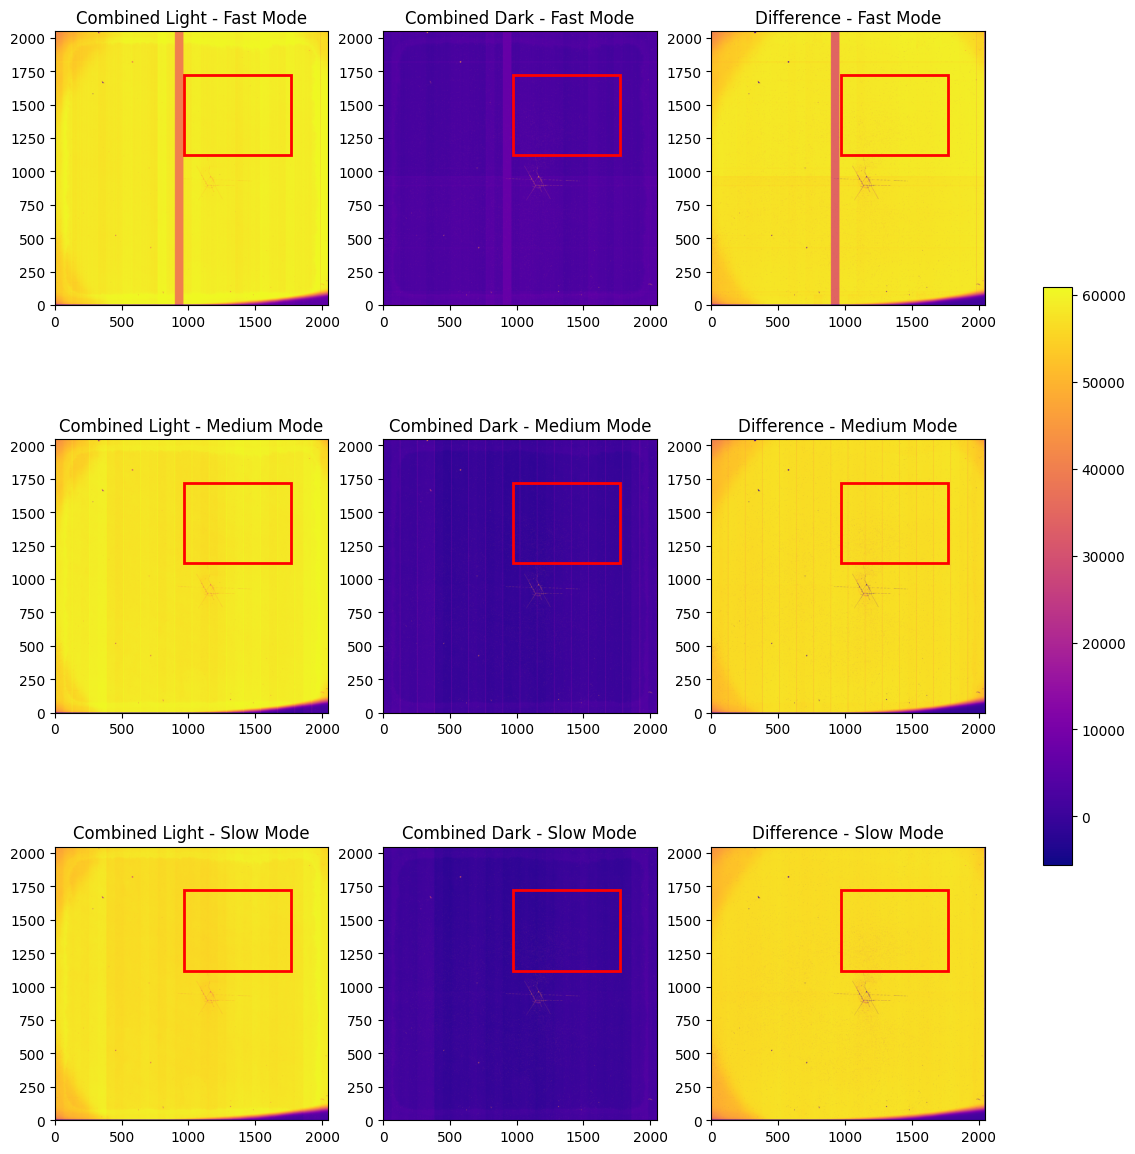

In [24]:
# Map filenames to titles for iteration
data_configs = [
    ("Fast", "fast_combined_light.fits", "fast_combined_dark.fits", "fast_diff.fits"),
    ("Medium", "medium_combined_light.fits", "medium_combined_dark.fits", "medium_diff.fits"),
    ("Slow", "slow_combined_light.fits", "slow_combined_dark.fits", "slow_diff.fits")
]

fig, axes = plt.subplots(3, 3, figsize=(15, 15))

# Iterate through the rows (modes) of the grid
for row_idx, (mode_name, light_f, dark_f, diff_f) in enumerate(data_configs):
    ## Map filenames to titles for iteration
    files = [light_f, dark_f, diff_f]
    titles = [f"Combined Light - {mode_name} Mode", f"Combined Dark - {mode_name} Mode", f"Difference - {mode_name} Mode"]
    
    ## Iterate through the columns (frame types) of the grid
    for col_idx, file in enumerate(files):
        ### Load data from FITS file
        data = fits.getdata(f"linearity/{file}")
        
        ### Plot the image
        ax = axes[row_idx, col_idx]
        im = ax.imshow(data[29, :, :], origin="lower", cmap="plasma")
        
        ### Add region of interest
        ax.add_patch(Rectangle((970, 1120), 800, 600, edgecolor='red', facecolor='none', lw=2))
        
        ### Set title for the subplot
        ax.set_title(titles[col_idx], size=12)

# Add colorbar to the whole figure
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.5)
plt.show()

Channels in medium & slow modes: read-out electronics

Extract data within the region of interest from all the combined and difference images

In [25]:
# Fast mode
fast_light = fits.getdata("linearity/fast_combined_light.fits")[:,970:1670,1120:1720]
fast_dark = fits.getdata("linearity/fast_combined_dark.fits")[:,970:1670,1120:1720]
fast_diff = fits.getdata("linearity/fast_diff.fits")[:,970:1670,1120:1720]

# Medium mode
medium_light = fits.getdata("linearity/medium_combined_light.fits")[:,970:1670,1120:1720]
medium_dark = fits.getdata("linearity/medium_combined_dark.fits")[:,970:1670,1120:1720]
medium_diff = fits.getdata("linearity/medium_diff.fits")[:,970:1670,1120:1720]

# Slow mode
slow_light = fits.getdata("linearity/slow_combined_light.fits")[:,970:1670,1120:1720]
slow_dark = fits.getdata("linearity/slow_combined_dark.fits")[:,970:1670,1120:1720]
slow_diff = fits.getdata("linearity/slow_diff.fits")[:,970:1670,1120:1720]

### b) Compute and plot the mean of pixel values in the chosen region

All modes together (for general perspective)

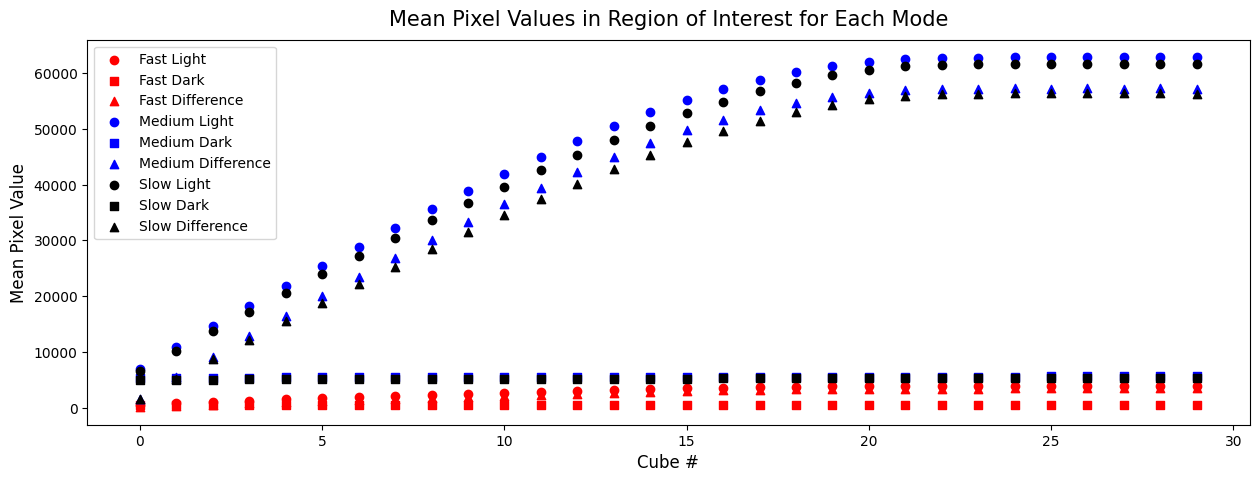

In [26]:
# Group data objects into a list for easy iteration
# Each tuple: (mode_name, data_3d, color)
modes = [
    ('Fast', fast_light, fast_dark, fast_diff, 'red'),
    ('Medium', medium_light, medium_dark, medium_diff, 'blue'),
    ('Slow', slow_light, slow_dark, slow_diff, 'black')
]
markers = ['o', 's', '^']

plt.figure(figsize=(15, 5))
plt.title("Mean Pixel Values in Region of Interest for Each Mode", size=15, y=1.015)
plt.xlabel("Cube #", size=12)
plt.ylabel("Mean Pixel Value", size=12)

# Plotting loop
for i in range(30):
    for name, light, dark, diff, color in modes:
        # Dictionary mapping frame names to their respective data slices
        frame_data = {'Light': light[i, :, :], 'Dark': dark[i, :, :], 'Difference': diff[i, :, :]}
        
        for j, (frame_type, data_slice) in enumerate(frame_data.items()):
            plt.scatter(i, np.mean(data_slice), 
                        marker=markers[j], 
                        color=color, 
                        label=f'{name} {frame_type}' if i == 0 else "")

plt.legend()
plt.show()

Fast Mode

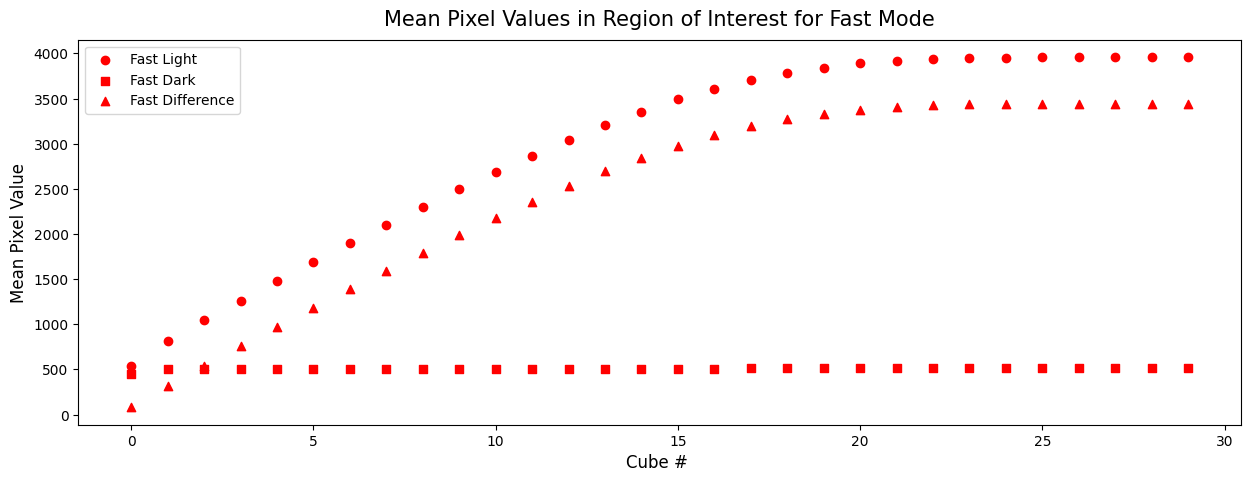

In [27]:
# Set up the figure and axes
plt.figure(figsize=(15, 5))
plt.title("Mean Pixel Values in Region of Interest for Fast Mode", size = 15, y=1.015)
plt.xlabel("Cube # ", size = 12)
plt.ylabel("Mean Pixel Value", size = 12)

# Define the marker color for each frame type
markers = ['o', 's', '^'] ## Circle for light, square for dark, triangle for difference

# Iterate over all the Cubes and calculate the mean pixel value in the region of interest
for i in range(0,30,1):
    # Compute the mean pixel value in the region of interest for the three frames of fast mode
    fast_light_mean = np.mean(fast_light[i, :, :])
    fast_dark_mean = np.mean(fast_dark[i, :, :])
    fast_diff_mean = np.mean(fast_diff[i, :, :])
    
    # Plot the mean pixel values
    plt.scatter(i, fast_light_mean, marker=markers[0], color="red", label='Fast Light' if i == 0 else "")
    plt.scatter(i, fast_dark_mean, marker=markers[1], color="red", label='Fast Dark' if i == 0 else "")
    plt.scatter(i, fast_diff_mean, marker=markers[2], color="red", label='Fast Difference' if i == 0 else "")

plt.legend()
plt.show()

Medium Mode

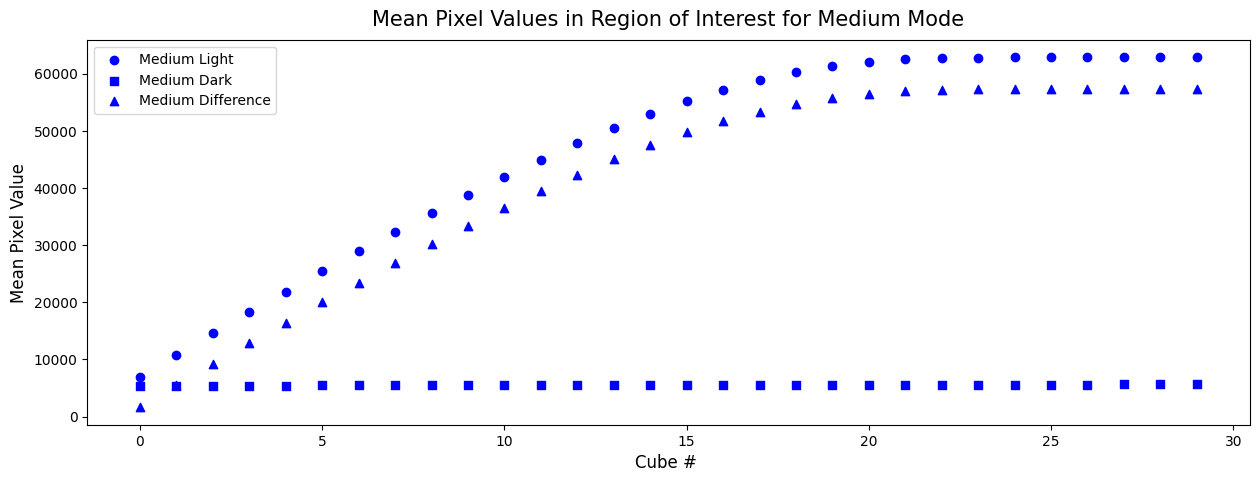

In [28]:
# Set up the figure and axes
plt.figure(figsize=(15, 5))
plt.title("Mean Pixel Values in Region of Interest for Medium Mode", size = 15, y=1.015)
plt.xlabel("Cube # ", size = 12)
plt.ylabel("Mean Pixel Value", size = 12)

# Define the marker color for each frame type
markers = ['o', 's', '^'] ## Circle for light, square for dark, triangle for difference

# Iterate over all the Cubes and calculate the mean pixel value in the region of interest
for i in range(0,30,1):
    # Compute the mean pixel value in the region of interest for the three frames of medium mode
    medium_light_mean = np.mean(medium_light[i, :, :])
    medium_dark_mean = np.mean(medium_dark[i, :, :])
    medium_diff_mean = np.mean(medium_diff[i, :, :])
    
    # Plot the mean pixel values
    plt.scatter(i, medium_light_mean, marker=markers[0], color="blue", label='Medium Light' if i == 0 else "")
    plt.scatter(i, medium_dark_mean, marker=markers[1], color="blue", label='Medium Dark' if i == 0 else "")
    plt.scatter(i, medium_diff_mean, marker=markers[2], color="blue", label='Medium Difference' if i == 0 else "")

plt.legend()
plt.show()

Slow Mode

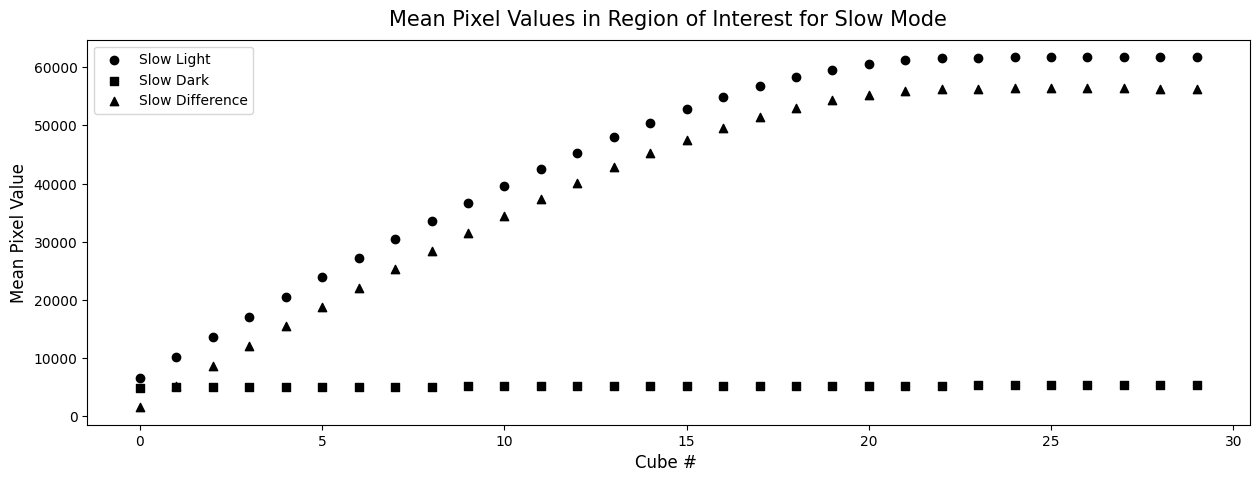

In [29]:
# Set up the figure and axes
plt.figure(figsize=(15, 5))
plt.title("Mean Pixel Values in Region of Interest for Slow Mode", size = 15, y=1.015)
plt.xlabel("Cube # ", size = 12)
plt.ylabel("Mean Pixel Value", size = 12)

# Define the marker color for each frame type
markers = ['o', 's', '^'] ## Circle for light, square for dark, triangle for difference

# Iterate over all the Cubes and calculate the mean pixel value in the region of interest
for i in range(0,30,1):
    # Compute the mean pixel value in the region of interest for the three frames of slow mode
    slow_light_mean = np.mean(slow_light[i, :, :])
    slow_dark_mean = np.mean(slow_dark[i, :, :])
    slow_diff_mean = np.mean(slow_diff[i, :, :])
    
    # Plot the mean pixel values
    plt.scatter(i, slow_light_mean, marker=markers[0], color="black", label='Slow Light' if i == 0 else "")
    plt.scatter(i, slow_dark_mean, marker=markers[1], color="black", label='Slow Dark' if i == 0 else "")
    plt.scatter(i, slow_diff_mean, marker=markers[2], color="black", label='Slow Difference' if i == 0 else "")

plt.legend()
plt.show()

### c) Compute and plot the median of pixel values in the chosen region

All modes together

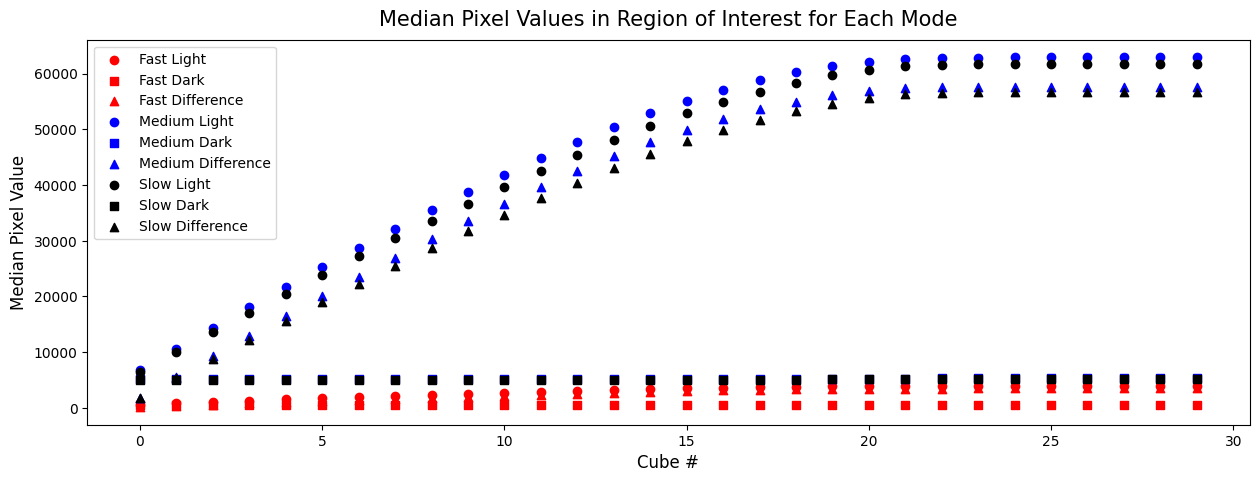

In [30]:
# Group data objects into a list for easy iteration
# Each tuple: (mode_name, data_3d, color)
modes = [
    ('Fast', fast_light, fast_dark, fast_diff, 'red'),
    ('Medium', medium_light, medium_dark, medium_diff, 'blue'),
    ('Slow', slow_light, slow_dark, slow_diff, 'black')
]
markers = ['o', 's', '^']

plt.figure(figsize=(15, 5))
plt.title("Median Pixel Values in Region of Interest for Each Mode", size=15, y=1.015)
plt.xlabel("Cube #", size=12)
plt.ylabel("Median Pixel Value", size=12)

# Plotting loop
for i in range(30):
    for name, light, dark, diff, color in modes:
        # Dictionary mapping frame names to their respective data slices
        frame_data = {'Light': light[i, :, :], 'Dark': dark[i, :, :], 'Difference': diff[i, :, :]}
        
        for j, (frame_type, data_slice) in enumerate(frame_data.items()):
            plt.scatter(i, np.median(data_slice), 
                        marker=markers[j], 
                        color=color, 
                        label=f'{name} {frame_type}' if i == 0 else "")

plt.legend()
plt.show()

Fast Mode

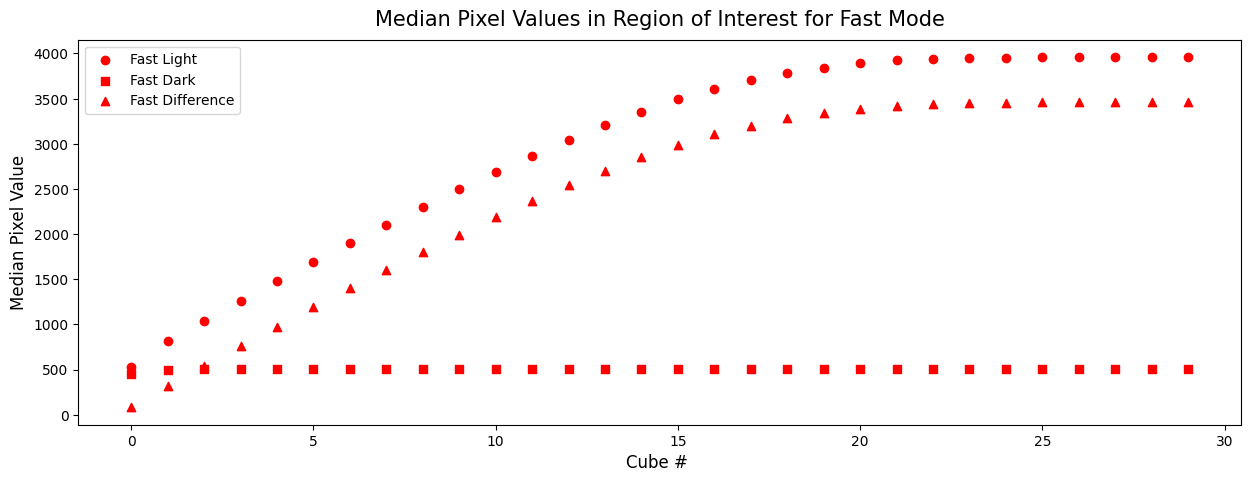

In [31]:
# Set up the figure and axes
plt.figure(figsize=(15, 5))
plt.title("Median Pixel Values in Region of Interest for Fast Mode", size = 15, y=1.015)
plt.xlabel("Cube # ", size = 12)
plt.ylabel("Median Pixel Value", size = 12)

# Define the marker color for each frame type
markers = ['o', 's', '^'] ## Circle for light, square for dark, triangle for difference

# Iterate over all the Cubes and calculate the mean pixel value in the region of interest
for i in range(0,30,1):
    # Compute the mean pixel value in the region of interest for the three frames of fast mode
    fast_light_mean = np.median(fast_light[i, :, :])
    fast_dark_mean = np.median(fast_dark[i, :, :])
    fast_diff_mean = np.median(fast_diff[i, :, :])
    
    # Plot the mean pixel values
    plt.scatter(i, fast_light_mean, marker=markers[0], color="red", label='Fast Light' if i == 0 else "")
    plt.scatter(i, fast_dark_mean, marker=markers[1], color="red", label='Fast Dark' if i == 0 else "")
    plt.scatter(i, fast_diff_mean, marker=markers[2], color="red", label='Fast Difference' if i == 0 else "")

plt.legend()
plt.show()

Medium Mode

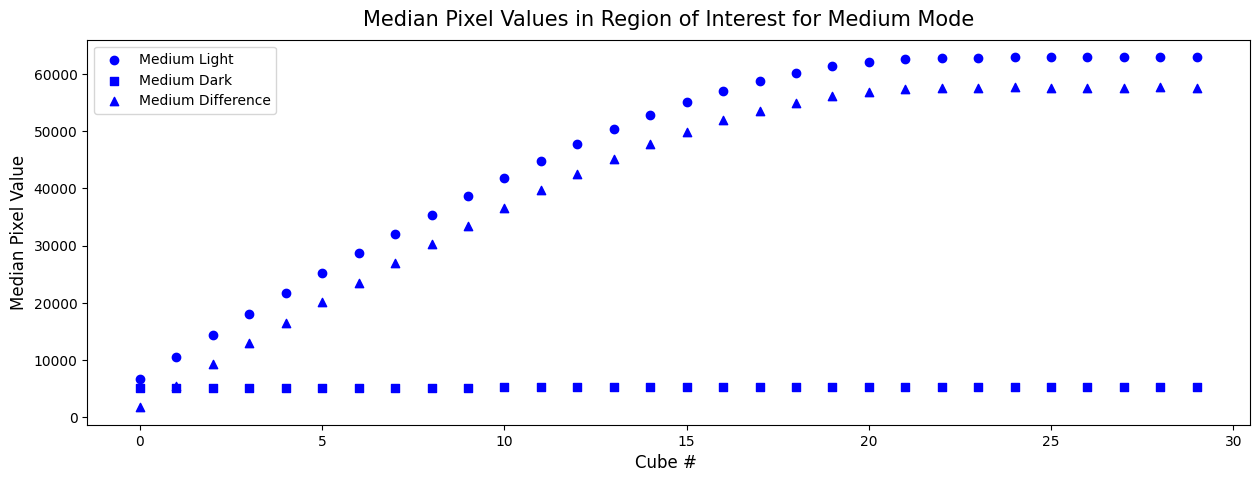

In [32]:
# Set up the figure and axes
plt.figure(figsize=(15, 5))
plt.title("Median Pixel Values in Region of Interest for Medium Mode", size = 15, y=1.015)
plt.xlabel("Cube # ", size = 12)
plt.ylabel("Median Pixel Value", size = 12)

# Define the marker color for each frame type
markers = ['o', 's', '^'] ## Circle for light, square for dark, triangle for difference

# Iterate over all the Cubes and calculate the mean pixel value in the region of interest
for i in range(0,30,1):
    # Compute the mean pixel value in the region of interest for the three frames of medium mode
    medium_light_mean = np.median(medium_light[i, :, :])
    medium_dark_mean = np.median(medium_dark[i, :, :])
    medium_diff_mean = np.median(medium_diff[i, :, :])
    
    # Plot the mean pixel values
    plt.scatter(i, medium_light_mean, marker=markers[0], color="blue", label='Medium Light' if i == 0 else "")
    plt.scatter(i, medium_dark_mean, marker=markers[1], color="blue", label='Medium Dark' if i == 0 else "")
    plt.scatter(i, medium_diff_mean, marker=markers[2], color="blue", label='Medium Difference' if i == 0 else "")

plt.legend()
plt.show()

Slow Mode

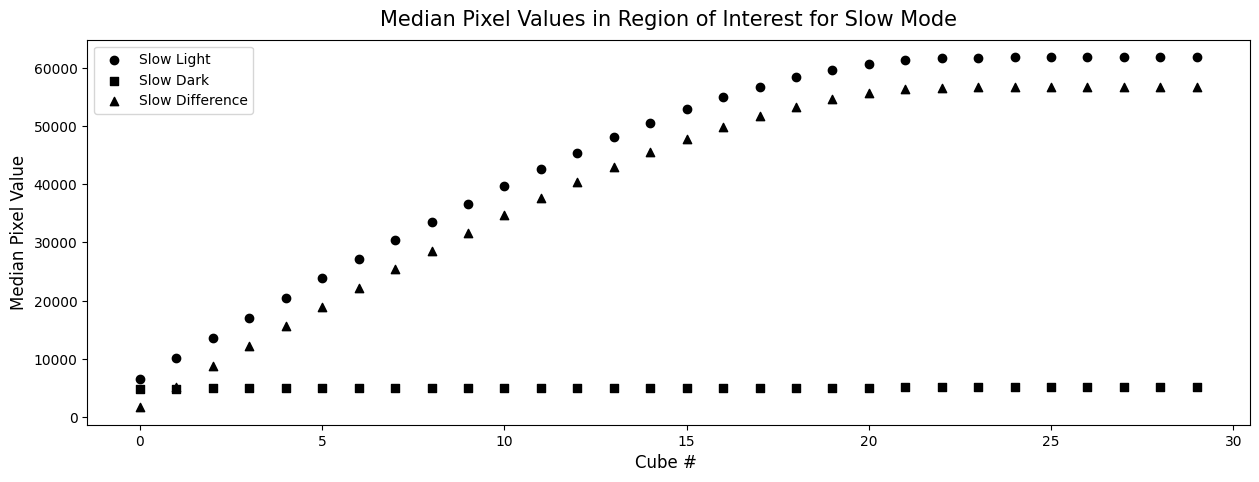

In [33]:
# Set up the figure and axes
plt.figure(figsize=(15, 5))
plt.title("Median Pixel Values in Region of Interest for Slow Mode", size = 15, y=1.015)
plt.xlabel("Cube # ", size = 12)
plt.ylabel("Median Pixel Value", size = 12)

# Define the marker color for each frame type
markers = ['o', 's', '^'] ## Circle for light, square for dark, triangle for difference

# Iterate over all the Cubes and calculate the mean pixel value in the region of interest
for i in range(0,30,1):
    # Compute the mean pixel value in the region of interest for the three frames of slow mode
    slow_light_mean = np.median(slow_light[i, :, :])
    slow_dark_mean = np.median(slow_dark[i, :, :])
    slow_diff_mean = np.median(slow_diff[i, :, :])
    
    # Plot the mean pixel values
    plt.scatter(i, slow_light_mean, marker=markers[0], color="black", label='Slow Light' if i == 0 else "")
    plt.scatter(i, slow_dark_mean, marker=markers[1], color="black", label='Slow Dark' if i == 0 else "")
    plt.scatter(i, slow_diff_mean, marker=markers[2], color="black", label='Slow Difference' if i == 0 else "")

plt.legend()
plt.show()

**Mean and median are the same from above, so use mean from now on**

# **Week 3: May 28 - June 3**

## 1) Identify linear data points for light and difference frames for each mode

Determine linearity of mean data points using Pearson r-value from `scipy.stats.pearsonr`: <https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.pearsonr.html>

In [34]:
from scipy import stats
import copy

In [35]:
# Create a mapping of keys to their respective 3D arrays
data_map = {
    "Fast Light": fast_light,
    "Fast Diff": fast_diff,
    "Medium Light": medium_light,
    "Medium Diff": medium_diff,
    "Slow Light": slow_light,
    "Slow Diff": slow_diff
}

# Iterate over all mapping keys
mean_pixel_values = {}
for key, data in data_map.items():
    ## Calculate the mean pixel value across the spatial dimensions (axis 1 and 2) for each cube (axis 0)
    mean_pixel_values[key] = np.mean(data, axis=(1, 2))
linear_data = copy.deepcopy(mean_pixel_values) ## Duplicate of mean pixel values to preserve original data for later calculations

# Iterate over the mean pixel values for each key and remove non-linear points based on Pearson correlation coefficient
i = 29
while i >= 1:
    for k in linear_data:
        ## Calculate the Pearson correlation coefficient between cube number and mean pixel value
        r, p = stats.pearsonr(np.arange(i+1), linear_data[k][:i+1])
        
        ## Use threshold of r = 0.999 to determine if data is linear enough
        ## If current data array does not pass the threshold, remove the last point and check again
        if abs(r) < 0.999:
            linear_data[k] = linear_data[k][:i]  # Remove the last point
    i -= 1

### a) Fast Mode

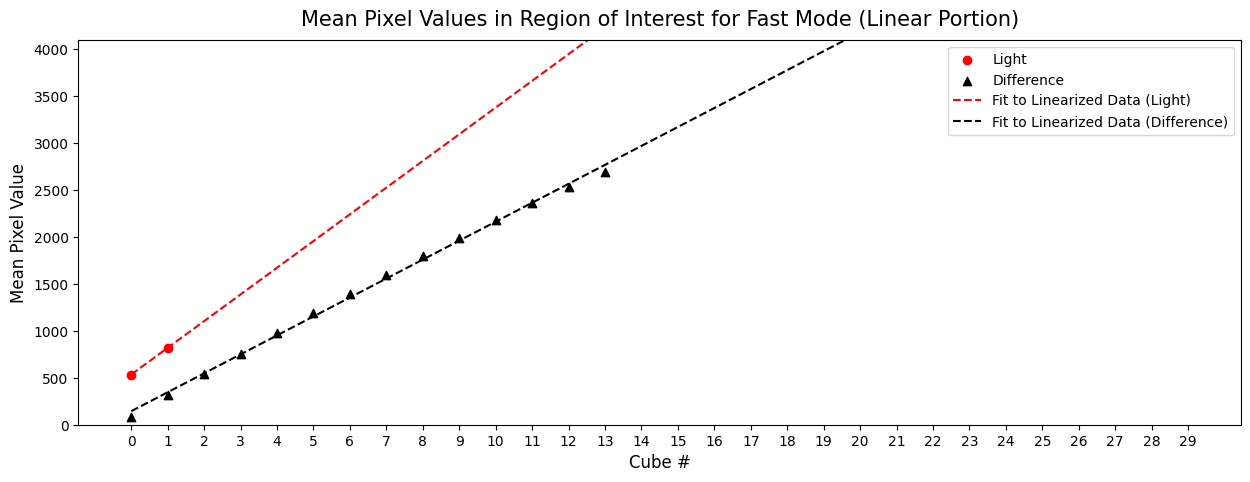

In [36]:
plt.figure(figsize=(15, 5))
plt.xlabel("Cube #", size=12)
plt.xticks(np.arange(0, 30, 1))
plt.ylabel("Mean Pixel Value", size=12)
plt.ylim(None, 4100)
plt.title("Mean Pixel Values in Region of Interest for Fast Mode (Linear Portion)", size=15, y=1.015)

# Plot the mean pixel values for each key after removing non-linear points
plt.scatter(np.arange(len(linear_data["Fast Light"])), linear_data["Fast Light"], label="Light", color="red", marker='o')
plt.scatter(np.arange(len(linear_data["Fast Diff"])), linear_data["Fast Diff"], label="Difference", color="black", marker='^')

# Fit a slope and intercept to the linear portion of the data
slope_fast_light, intercept_fast_light = np.polyfit(np.arange(len(linear_data["Fast Light"])), linear_data["Fast Light"], deg=1)
slope_fast_diff, intercept_fast_diff = np.polyfit(np.arange(len(linear_data["Fast Diff"])), linear_data["Fast Diff"], deg=1)

# Create the fit lines for plotting
fit_fast_light = slope_fast_light * np.arange(len(mean_pixel_values["Fast Light"])) + intercept_fast_light
fit_fast_diff = slope_fast_diff * np.arange(len(mean_pixel_values["Fast Diff"])) + intercept_fast_diff

# Fit lines over the linear portion of the data
plt.plot(np.arange(len(mean_pixel_values["Fast Light"])), fit_fast_light, label="Fit to Linearized Data (Light)", color="red", linestyle='dashed')
plt.plot(np.arange(len(mean_pixel_values["Fast Diff"])), fit_fast_diff, label="Fit to Linearized Data (Difference)", color="black", linestyle='dashed')

plt.legend()

### b) Medium Mode

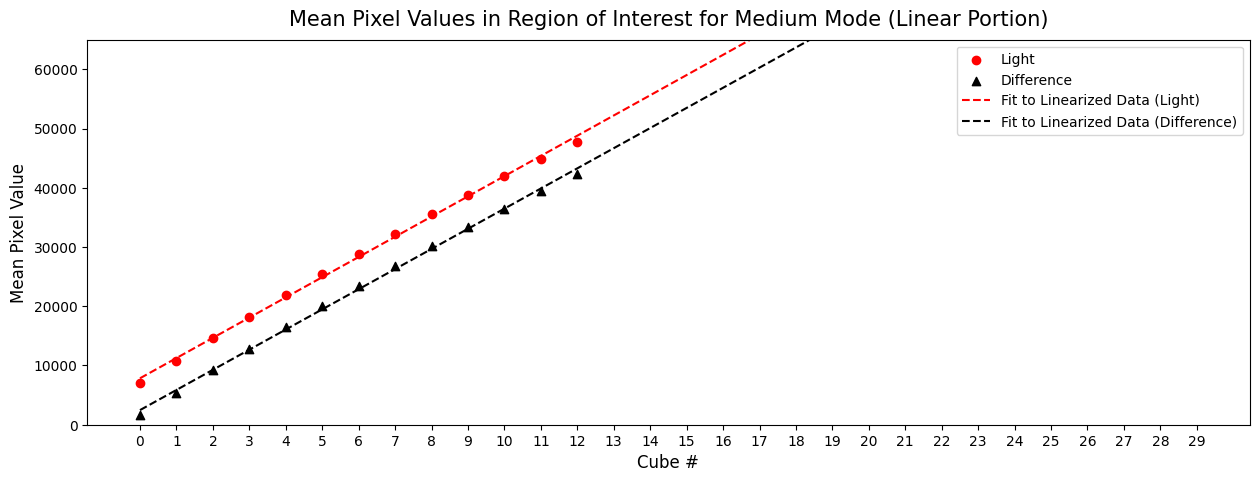

In [37]:
plt.figure(figsize=(15, 5))
plt.xlabel("Cube #", size=12)
plt.xticks(np.arange(0, 30, 1))
plt.ylabel("Mean Pixel Value", size=12)
plt.ylim(None, 65000)
plt.title("Mean Pixel Values in Region of Interest for Medium Mode (Linear Portion)", size=15, y=1.015)

# Plot the mean pixel values for each key after removing non-linear points
plt.scatter(np.arange(len(linear_data["Medium Light"])), linear_data["Medium Light"], label="Light", color="red", marker='o')
plt.scatter(np.arange(len(linear_data["Medium Diff"])), linear_data["Medium Diff"], label="Difference", color="black", marker='^')

# Fit a slope and intercept to the linear portion of the data
slope_medium_light, intercept_medium_light = np.polyfit(np.arange(len(linear_data["Medium Light"])), linear_data["Medium Light"], deg=1)
slope_medium_diff, intercept_medium_diff = np.polyfit(np.arange(len(linear_data["Medium Diff"])), linear_data["Medium Diff"], deg=1)

# Create the fit lines for plotting
fit_medium_light = slope_medium_light * np.arange(len(mean_pixel_values["Medium Light"])) + intercept_medium_light
fit_medium_diff = slope_medium_diff * np.arange(len(mean_pixel_values["Medium Diff"])) + intercept_medium_diff

# Fit lines over the linear portion of the data
plt.plot(np.arange(len(mean_pixel_values["Medium Light"])), fit_medium_light, label="Fit to Linearized Data (Light)", color="red", linestyle='dashed')
plt.plot(np.arange(len(mean_pixel_values["Medium Diff"])), fit_medium_diff, label="Fit to Linearized Data (Difference)", color="black", linestyle='dashed')
   
plt.legend()

### c) Slow Mode

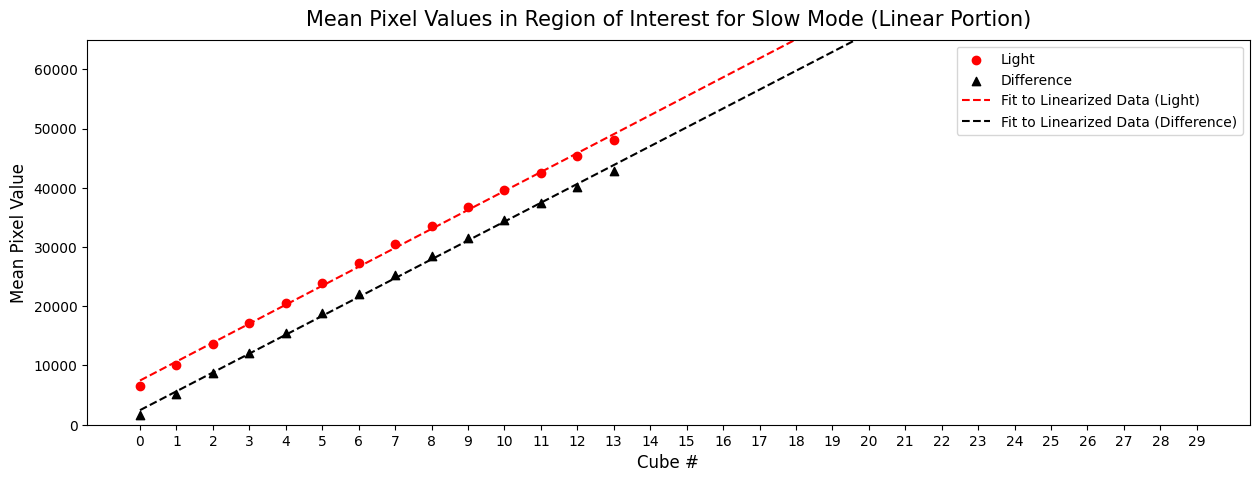

In [38]:
plt.figure(figsize=(15, 5))
plt.xlabel("Cube #", size=12)
plt.xticks(np.arange(0, 30, 1))
plt.ylabel("Mean Pixel Value", size=12)
plt.ylim(None, 65000)
plt.title("Mean Pixel Values in Region of Interest for Slow Mode (Linear Portion)", size=15, y=1.015)

# Plot the mean pixel values for each key after removing non-linear points
plt.scatter(np.arange(len(linear_data["Slow Light"])), linear_data["Slow Light"], label="Light", color="red", marker='o')
plt.scatter(np.arange(len(linear_data["Slow Diff"])), linear_data["Slow Diff"], label="Difference", color="black", marker='^')

# Fit a slope and intercept to the linear portion of the data
slope_slow_light, intercept_slow_light = np.polyfit(np.arange(len(linear_data["Slow Light"])), linear_data["Slow Light"], deg=1)
slope_slow_diff, intercept_slow_diff = np.polyfit(np.arange(len(linear_data["Slow Diff"])), linear_data["Slow Diff"], deg=1)

# Create the fit lines for plotting
fit_slow_light = slope_slow_light * np.arange(len(mean_pixel_values["Slow Light"])) + intercept_slow_light
fit_slow_diff = slope_slow_diff * np.arange(len(mean_pixel_values["Slow Diff"])) + intercept_slow_diff

# Fit lines over the linear portion of the data
plt.plot(np.arange(len(mean_pixel_values["Slow Light"])), fit_slow_light, label="Fit to Linearized Data (Light)", color="red", linestyle='dashed')
plt.plot(np.arange(len(mean_pixel_values["Slow Diff"])), fit_slow_diff, label="Fit to Linearized Data (Difference)", color="black", linestyle='dashed')

plt.legend()

## 2) Identify the 5% linear regime

### a) Fast Mode

<Figure size 1500x500 with 0 Axes>

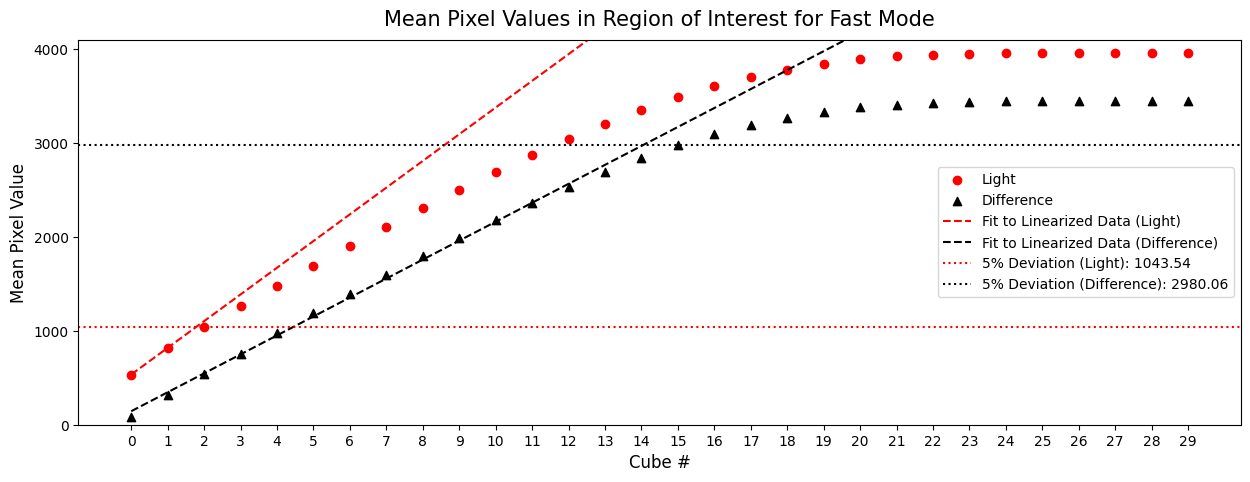

In [39]:
# Compute the difference between the fit line and non-linear data points
difference_fast_light = np.abs(mean_pixel_values["Fast Light"][len(linear_data["Fast Light"]):] - fit_fast_light[len(linear_data["Fast Light"]):])
difference_fast_diff = np.abs(mean_pixel_values["Fast Diff"][len(linear_data["Fast Diff"]):] - fit_fast_diff[len(linear_data["Fast Diff"]):])

# Identify the cube number where the difference exceeds the 5% deviation
threshold_fast_light = 0.05 * fit_fast_light[len(linear_data["Fast Light"]):]
threshold_fast_diff = 0.05 * fit_fast_diff[len(linear_data["Fast Diff"]):]
exceed_threshold_fast_light = np.nonzero(difference_fast_light > threshold_fast_light)[0][0] + len(linear_data["Fast Light"])
exceed_threshold_fast_diff = np.nonzero(difference_fast_diff > threshold_fast_diff)[0][0] + len(linear_data["Fast Diff"])

# Plot the mean pixel values and the fit lines for fast mode
plt.figure(figsize=(15, 5))
plt.figure(figsize=(15, 5))
plt.xlabel("Cube #", size=12)
plt.xticks(np.arange(0, 30, 1))
plt.ylabel("Mean Pixel Value", size=12)
plt.yticks(np.arange(0, 9500, 1000))
plt.ylim(0,4100)
plt.title("Mean Pixel Values in Region of Interest for Fast Mode", size=15, y=1.015)

## Mean pixel values over the entire range of cubes
plt.scatter(np.arange(len(mean_pixel_values["Fast Light"])), mean_pixel_values["Fast Light"], label="Light", color="red", marker='o')
plt.scatter(np.arange(len(mean_pixel_values["Fast Diff"])), mean_pixel_values["Fast Diff"], label="Difference", color="black", marker='^')

## Fit lines over the linear portion of the data
plt.plot(np.arange(len(mean_pixel_values["Fast Light"])), fit_fast_light, label="Fit to Linearized Data (Light)", color="red", linestyle='dashed')
plt.plot(np.arange(len(mean_pixel_values["Fast Diff"])), fit_fast_diff, label="Fit to Linearized Data (Difference)", color="black", linestyle='dashed')

## Plot the highest point that does not exceed the 5% deviation threshold
plt.axhline(y=mean_pixel_values["Fast Light"][exceed_threshold_fast_light], 
            color='red', linestyle='dotted', 
            label=f'5% Deviation (Light): {mean_pixel_values["Fast Light"][exceed_threshold_fast_light]:.2f}')
plt.axhline(y=mean_pixel_values["Fast Diff"][exceed_threshold_fast_diff], 
            color='black', linestyle='dotted', 
            label=f'5% Deviation (Difference): {mean_pixel_values["Fast Diff"][exceed_threshold_fast_diff]:.2f}')

plt.legend()

### b) Medium Mode

<Figure size 1500x500 with 0 Axes>

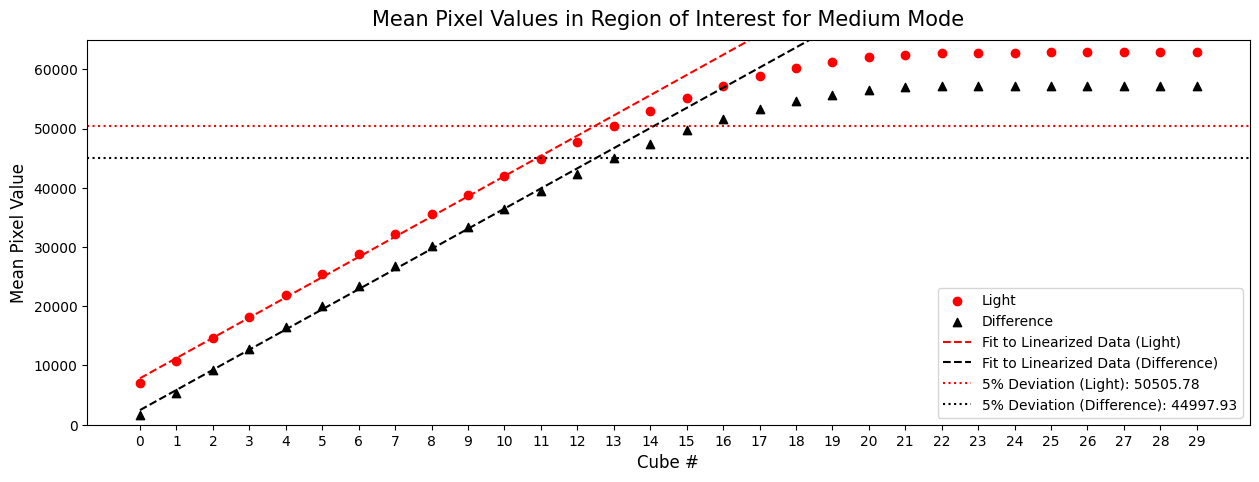

In [40]:
# Compute the difference between the fit line and non-linear data points
difference_medium_light = np.abs(mean_pixel_values["Medium Light"][len(linear_data["Medium Light"]):] - fit_fast_light[len(linear_data["Medium Light"]):])
difference_medium_diff = np.abs(mean_pixel_values["Medium Diff"][len(linear_data["Medium Diff"]):] - fit_fast_diff[len(linear_data["Medium Diff"]):])

# Identify the cube number where the difference exceeds the 5% deviation
threshold_medium_light = 0.05 * fit_medium_light[len(linear_data["Medium Light"]):]
threshold_medium_diff = 0.05 * fit_medium_diff[len(linear_data["Medium Diff"]):]
exceed_threshold_medium_light = np.nonzero(difference_medium_light > threshold_medium_light)[0][0] + len(linear_data["Medium Light"])
exceed_threshold_medium_diff = np.nonzero(difference_medium_diff > threshold_medium_diff)[0][0] + len(linear_data["Medium Diff"])

# Plot the mean pixel values and the fit lines for fast mode
plt.figure(figsize=(15, 5))
plt.figure(figsize=(15, 5))
plt.xlabel("Cube #", size=12)
plt.xticks(np.arange(0, 30, 1))
plt.ylabel("Mean Pixel Value", size=12)
plt.ylim(None, 65000)
plt.title("Mean Pixel Values in Region of Interest for Medium Mode", size=15, y=1.015)

## Mean pixel values over the entire range of cubes
plt.scatter(np.arange(len(mean_pixel_values["Medium Light"])), mean_pixel_values["Medium Light"], label="Light", color="red", marker='o')
plt.scatter(np.arange(len(mean_pixel_values["Medium Diff"])), mean_pixel_values["Medium Diff"], label="Difference", color="black", marker='^')

## Fit lines over the linear portion of the data
plt.plot(np.arange(len(mean_pixel_values["Medium Light"])), fit_medium_light, label="Fit to Linearized Data (Light)", color="red", linestyle='dashed')
plt.plot(np.arange(len(mean_pixel_values["Medium Diff"])), fit_medium_diff, label="Fit to Linearized Data (Difference)", color="black", linestyle='dashed')

## Plot the highest point that does not exceed the 5% deviation threshold
plt.axhline(y=mean_pixel_values["Medium Light"][exceed_threshold_medium_light], 
            color='red', linestyle='dotted', 
            label=f'5% Deviation (Light): {mean_pixel_values["Medium Light"][exceed_threshold_medium_light]:.2f}')
plt.axhline(y=mean_pixel_values["Medium Diff"][exceed_threshold_medium_diff], 
            color='black', linestyle='dotted', 
            label=f'5% Deviation (Difference): {mean_pixel_values["Medium Diff"][exceed_threshold_medium_diff]:.2f}')

plt.legend()

### c) Slow Mode

<Figure size 1500x500 with 0 Axes>

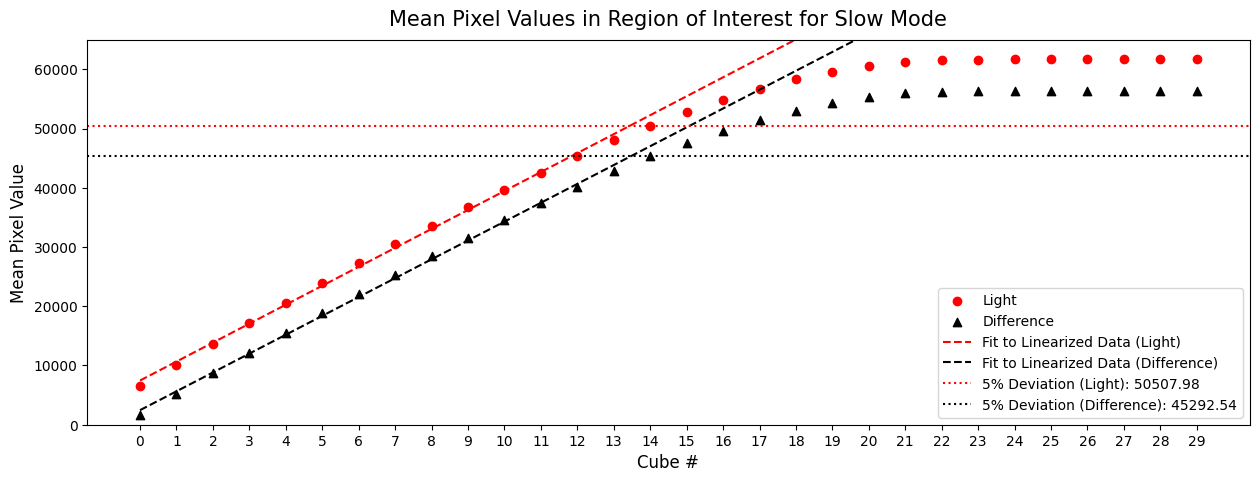

In [41]:
# Compute the difference between the fit line and non-linear data points
difference_slow_light = np.abs(mean_pixel_values["Slow Light"][len(linear_data["Slow Light"]):] - fit_fast_light[len(linear_data["Slow Light"]):])
difference_slow_diff = np.abs(mean_pixel_values["Slow Diff"][len(linear_data["Slow Diff"]):] - fit_fast_diff[len(linear_data["Slow Diff"]):])

# Identify the cube number where the difference exceeds the 5% deviation
threshold_slow_light = 0.05 * fit_slow_light[len(linear_data["Slow Light"]):]
threshold_slow_diff = 0.05 * fit_slow_diff[len(linear_data["Slow Diff"]):]
exceed_threshold_slow_light = np.nonzero(difference_slow_light > threshold_slow_light)[0][0] + len(linear_data["Slow Light"])
exceed_threshold_slow_diff = np.nonzero(difference_slow_diff > threshold_slow_diff)[0][0] + len(linear_data["Slow Diff"])

# Plot the mean pixel values and the fit lines for fast mode
plt.figure(figsize=(15, 5))
plt.figure(figsize=(15, 5))
plt.xlabel("Cube #", size=12)
plt.xticks(np.arange(0, 30, 1))
plt.ylabel("Mean Pixel Value", size=12)
plt.ylim(None, 65000)
plt.title("Mean Pixel Values in Region of Interest for Slow Mode", size=15, y=1.015)

## Mean pixel values over the entire range of cubes
plt.scatter(np.arange(len(mean_pixel_values["Slow Light"])), mean_pixel_values["Slow Light"], label="Light", color="red", marker='o')
plt.scatter(np.arange(len(mean_pixel_values["Slow Diff"])), mean_pixel_values["Slow Diff"], label="Difference", color="black", marker='^')

## Fit lines over the linear portion of the data
plt.plot(np.arange(len(mean_pixel_values["Slow Light"])), fit_slow_light, label="Fit to Linearized Data (Light)", color="red", linestyle='dashed')
plt.plot(np.arange(len(mean_pixel_values["Slow Diff"])), fit_slow_diff, label="Fit to Linearized Data (Difference)", color="black", linestyle='dashed')

## Plot the highest point that does not exceed the 5% deviation threshold
plt.axhline(y=mean_pixel_values["Slow Light"][exceed_threshold_slow_light], 
            color='red', linestyle='dotted', 
            label=f'5% Deviation (Light): {mean_pixel_values["Slow Light"][exceed_threshold_slow_light]:.2f}')
plt.axhline(y=mean_pixel_values["Slow Diff"][exceed_threshold_slow_diff], 
            color='black', linestyle='dotted', 
            label=f'5% Deviation (Difference): {mean_pixel_values["Slow Diff"][exceed_threshold_slow_diff]:.2f}')

plt.legend()

# **Week 4: June 4 - June 10**

## 1) Create the mean dark (superdark) frame

In [ ]:
# Call in all file names for dark images
distortion_dark_filenames = glob.glob('distortion\\darks\\*')

# Create an empty directory to store the data from dark frames
distortion_dark_frames = [None] * len(distortion_dark_filenames)

# Extract data from our set of dark frames
for i, filename in enumerate(distortion_dark_filenames):
    image_data = fits.getdata(filename)
    distortion_dark_frames[i] = image_data
distortion_dark_frames = np.array(distortion_dark_frames)

# Create the mean dark image
distortion_superdark = np.average(distortion_dark_frames,axis=0)
print(distortion_superdark.shape)

# Extract the header of the first dark frame
info_distortion_dark = fits.getheader(distortion_dark_filenames[0])

# Add reduction notes to header
superdark_hdr = fits.Header()
superdark_hdr = info_distortion_dark
superdark_hdr["Reduction"] = "Averaging 50 frames with exposure of 0.302s each"

# Write the mean dark image data with updated header to a new FITS file
mean_dark = fits.PrimaryHDU(data=distortion_superdark, header=superdark_hdr)
mean_dark.writeto("distortion/superdark.fits", overwrite=True)

(2, 2048, 2048)


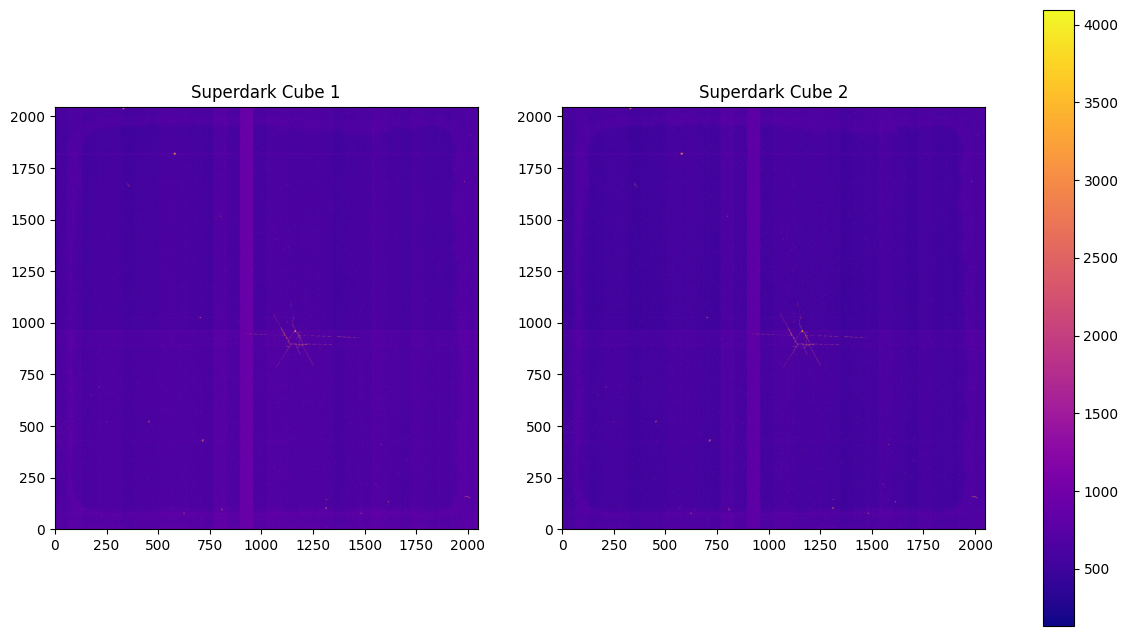

In [52]:
# Extract the data and header from the superdark image for further analysis
superdark_imagedata = fits.getdata("distortion/superdark.fits")
superdark_imageheaders = fits.getheader("distortion/superdark.fits")

# Plot both Cubes of the superdark image to check for any anomalies
fig, axes = plt.subplots(1, 2, figsize=(15, 10))
for i in range (superdark_imagedata.shape[0]):
    im = axes[i].imshow(superdark_imagedata[i, :, :], origin="lower", cmap="plasma")
    axes[i].set_title(f"Superdark Cube {i+1}", size=12)

# Show the colorbar for the superdark image
fig.colorbar(im, ax=axes.ravel().tolist(),shrink=0.8)
plt.show()

## 2) Create the normalized mean pseudo-flat (normalized superflat) frame

In [ ]:
# Call in all file names for pseudo-flat images
distortion_pseudoflat_filenames = glob.glob('distortion\\pseudo_flats\\*')

# Create an empty directory to store the data from pseudo-flat frames
distortion_pseudoflat_frames = [None] * len(distortion_pseudoflat_filenames)

# Extract data from our set of pseudo-flat frames
for i, filename in enumerate(distortion_pseudoflat_filenames):
    image_data = fits.getdata(filename)
    distortion_pseudoflat_frames[i] = image_data
distortion_pseudoflat_frames = np.array(distortion_pseudoflat_frames)

# Create the normalized mean pseudo-flat image
distortion_superflat = np.average(distortion_pseudoflat_frames,axis=0)
distortion_normalized_superflat = distortion_superflat - distortion_superdark / np.median(distortion_superflat - distortion_superdark)
print(distortion_normalized_superflat.shape)

# Extract the header of the first pseudo-flat frame
info_distortion_normalized_superflat = fits.getheader(distortion_pseudoflat_filenames[0])

# Add reduction notes to header
normalized_superflat_hdr = fits.Header()
normalized_superflat_hdr = info_distortion_normalized_superflat
normalized_superflat_hdr["Reduction"] = "Averaging 50 frames with exposure of 0.302s each"

# Write the mean dark image data with updated header to a new FITS file
normalized_mean_flat = fits.PrimaryHDU(data=distortion_normalized_superflat, header=normalized_superflat_hdr)
mean_dark.writeto("distortion/normalized_superflat.fits", overwrite=True)

(2, 2048, 2048)


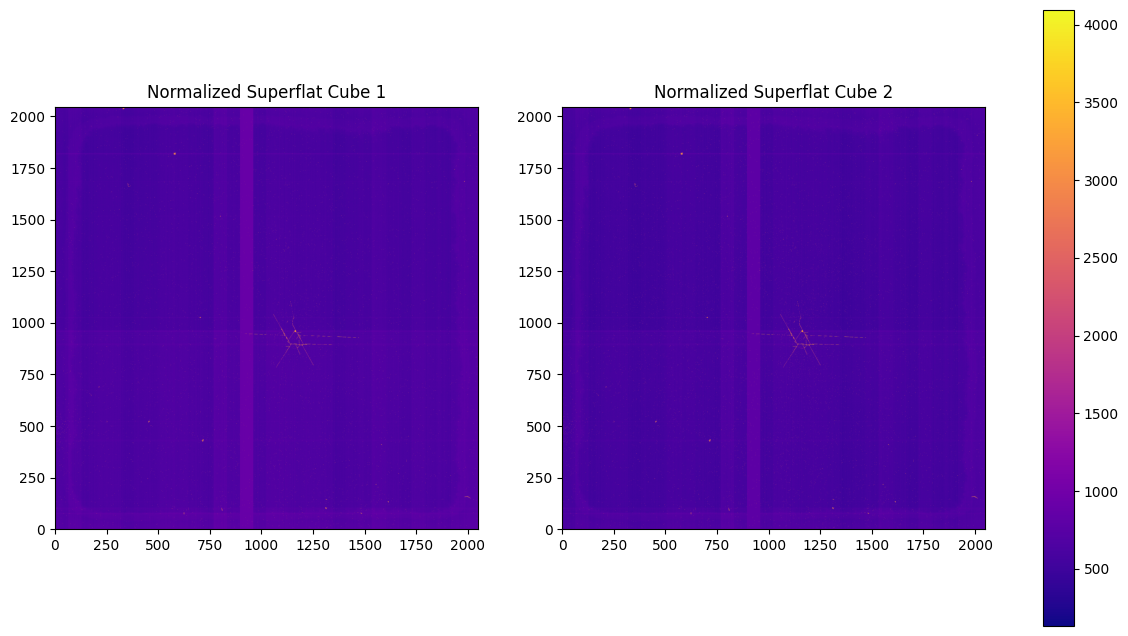

In [55]:
# Extract the data and header from the normalized superflat image for further analysis
normalized_superflat_imagedata = fits.getdata("distortion/normalized_superflat.fits")
normalized_superflat_imageheaders = fits.getheader("distortion/normalized_superflat.fits")

# Plot both Cubes of the superdark image to check for any anomalies
fig, axes = plt.subplots(1, 2, figsize=(15, 10))
for i in range (normalized_superflat_imagedata.shape[0]):
    im = axes[i].imshow(normalized_superflat_imagedata[i, :, :], origin="lower", cmap="plasma")
    axes[i].set_title(f"Normalized Superflat Cube {i+1}", size=12)

# Show the colorbar for the superdark image
fig.colorbar(im, ax=axes.ravel().tolist(),shrink=0.8)
plt.show()

## 3) Reduce the distortion data

In [63]:
# Call in all file names for distortion images
distortion_filenames = glob.glob('distortion\\distortions\\*')
distortion_filenames = np.array(distortion_filenames)

# Iterate through the distortion image and reduce each image
for f in distortion_filenames:
    ## Extract the data and header from the current distortion image
    distortion_imagedata = fits.getdata(f)
    distortion_imageheaders = fits.getheader(f)
    
    ## Reduce the current distortion image by subtracting the superdark and dividing by the normalized superflat
    reduced_distortion = (distortion_imagedata - distortion_superdark) / distortion_normalized_superflat
    
    ## Add reduction notes to header
    reduced_distortion_hdr = fits.Header()
    reduced_distortion_hdr = distortion_imageheaders
    reduced_distortion_hdr["Reduction"] = "Dark subtraction and (pseudo) flat fielding"
    
    ## Write the reduced distortion image data with updated header to a new FITS file
    reduced_distortion_hdu = fits.PrimaryHDU(data=reduced_distortion, header=reduced_distortion_hdr)
    output_filename = "distortion\\reduced_distortions\\reduced_" + f.split("\\")[-1]
    reduced_distortion_hdu.writeto(output_filename, overwrite=True)